In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'c:\Users\User\OneDrive\Desktop\supermarket_sales.csv')

#preview dataset
print(df.head())

   Invoice ID Branch        City Customer type  Gender  \
0        1000      A    Lalitpur        Member    Male   
1        1001      C  Biratnagar        Normal    Male   
2        1002      A      Butwal        Normal  Female   
3        1003      B     Pokhara        Normal  Female   
4        1004      C      Butwal        Member    Male   

             Product line  Unit price  Quantity        Date      Payment  \
0  Electronic accessories         349         7    8/5/2025  Credit card   
1      Food and beverages         166         4   10/7/2025  Credit card   
2       Sports and travel         593         7  11/10/2025      Ewallet   
3     Fashion accessories         733         2  10/18/2025  Credit card   
4       Sports and travel         900         4   2/11/2026         Cash   

   Total  
0   2443  
1    664  
2   4151  
3   1466  
4   3600  


In [3]:
#shape of dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 11)


In [4]:
#Data types
print(df.dtypes)

Invoice ID        int64
Branch           object
City             object
Customer type    object
Gender           object
Product line     object
Unit price        int64
Quantity          int64
Date             object
Payment          object
Total             int64
dtype: object


In [5]:
#summary statistics
print(df.describe())

        Invoice ID   Unit price     Quantity        Total
count  1000.000000  1000.000000  1000.000000  1000.000000
mean   1499.500000   550.089000     5.374000  2986.192000
std     288.819436   256.056013     2.870952  2254.289347
min    1000.000000   100.000000     1.000000   106.000000
25%    1249.750000   331.000000     3.000000  1084.750000
50%    1499.500000   539.500000     5.000000  2427.000000
75%    1749.250000   770.500000     8.000000  4401.000000
max    1999.000000  1000.000000    10.000000  9940.000000


In [6]:
#checking missing values
print(df.isnull (). sum())

Invoice ID       0
Branch           0
City             0
Customer type    0
Gender           0
Product line     0
Unit price       0
Quantity         0
Date             0
Payment          0
Total            0
dtype: int64


In [7]:
#Converting date column to datetime
df["Date"] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

#Check duplicates
print("Duplicated rows:", df.duplicated().sum())
print(df.info())

Duplicated rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice ID     1000 non-null   int64         
 1   Branch         1000 non-null   object        
 2   City           1000 non-null   object        
 3   Customer type  1000 non-null   object        
 4   Gender         1000 non-null   object        
 5   Product line   1000 non-null   object        
 6   Unit price     1000 non-null   int64         
 7   Quantity       1000 non-null   int64         
 8   Date           1000 non-null   datetime64[ns]
 9   Payment        1000 non-null   object        
 10  Total          1000 non-null   int64         
 11  Month          1000 non-null   int32         
 12  Day            1000 non-null   int32         
 13  Year           1000 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(4), object(6)
me

In [8]:
#Total Sales 
total_sales = df['Total'].sum()
print("Total sales:", total_sales)

Total sales: 2986192


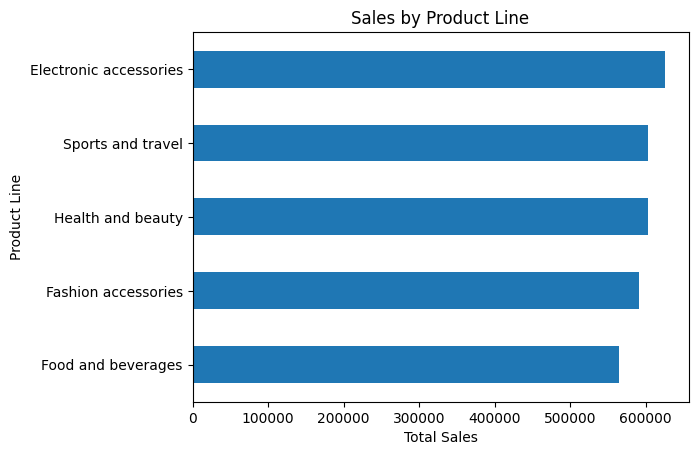

In [9]:
#sales by product line
product_sales = df.groupby('Product line')['Total'].sum().sort_values()
plt.figure()
product_sales.plot(kind='barh')
plt.title("Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.show()

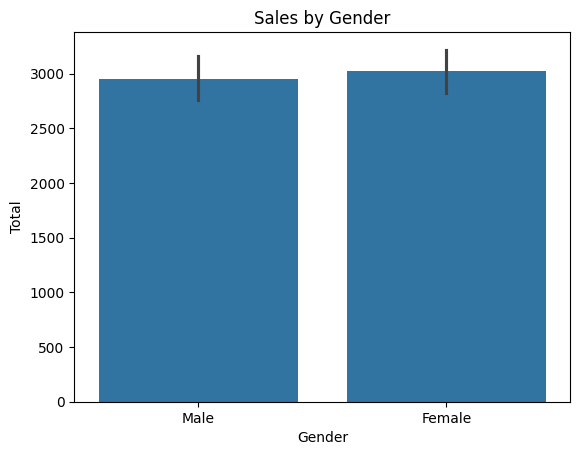

In [10]:
#Sales by Gender
plt.figure()
sns.barplot(x = "Gender", y = "Total", data = df)
plt.title("Sales by Gender")
plt.show()

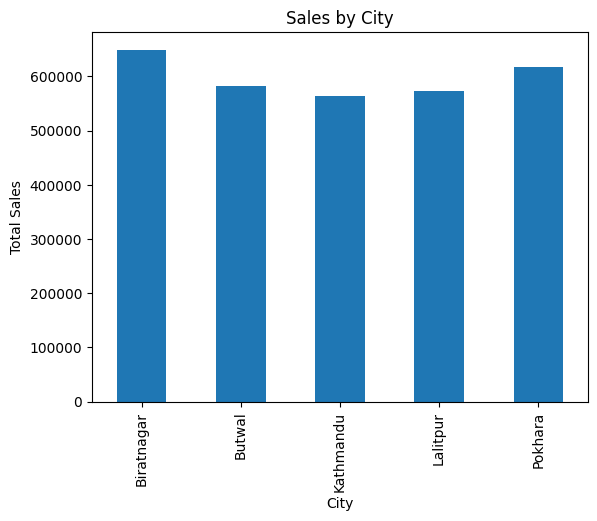

In [11]:
#sales by city
city_sales = df.groupby('City')['Total'].sum()
plt.figure()
city_sales.plot(kind='bar')
plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

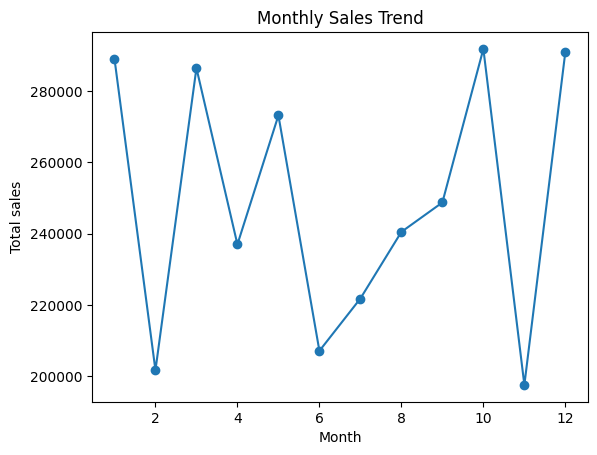

In [12]:
# Monthly sales trend
monthly_sales = df.groupby("Month")["Total"].sum()
plt.figure()
monthly_sales.plot(marker = "o")
plt.title ("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.show()


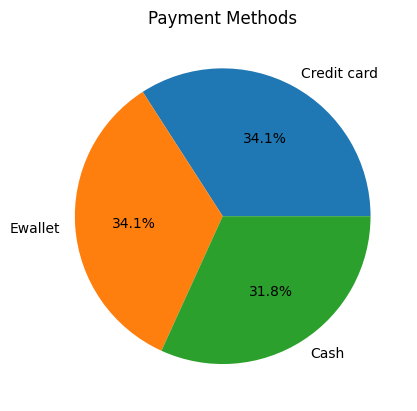

In [14]:
#payment method distribution
plt.figure()
df['Payment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Methods")
plt.ylabel("")
plt.show()

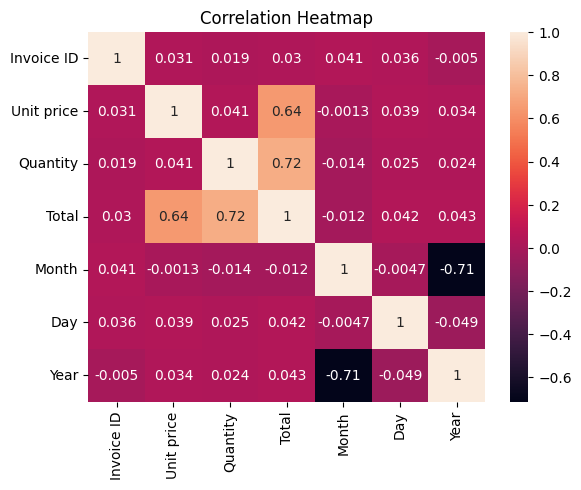

In [16]:
#correlation heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()